<a href="https://colab.research.google.com/github/kaxmarc/statistics_ml/blob/main/individual_exercise/exercise_2-2/exercise_2_2_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chapter 2 - Individual Exercise 2 – Applying and Evaluating Supervised Learning Models
by Kay Müller

Dataset: **Breast Cancer Wisconsin**

Source: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic | sklearn.datasets > load_breast_cancer

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline

##1. Tree-Based Models

Implement three different tree-based classification models using scikit-learn:

Decision Tree Classifier

Random Forest Classifier

Gradient Boosted Trees Classifier

Train each model and generate predictions on the test set.

###1.1 Preparation

In [30]:
# Load Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df_optimised = df.copy()

# Check Missing Values
missing_values = df_optimised.isnull().sum().sort_values(ascending=False)
if missing_values.sum() > 0: print(f"\n{'='*55}\nImportant: Edit missing values!\n{'='*55}")

"""
# In the case of categorical features
numerical_col = df_optimised.select_dtypes(include=np.number).columns.tolist()
categorical_col = df_optimised.select_dtypes(include=['object', 'category']).columns.tolist()
df_optimised = pd.get_dummies(df_optimised, columns=categorical_col, drop_first=False)
"""

X = df_optimised.drop('target', axis=1)
y = df_optimised['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42
)
print(f"Training data 80%: {X_train.shape[0]} Samples",
      f"\nTest data 20%:     {y_test.shape[0]} Samples"
)

Training data 80%: 455 Samples 
Test data 20%:     114 Samples


###1.2 Tree-based training

**Decision Tree Classifier**

In [31]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

print("Decision Tree Classifier Report:")
print("\n", classification_report(y_test, y_pred_dt, target_names=data.target_names))

Decision Tree Classifier Report:

               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



The decision tree is designed for recursive search for the best feature split. Due to its structure, this model tends to overfit, as it is trained in great detail. The report presents the test set consisting of 43 malignant and 71 benign cases.


Precision: How often was the prediction correct (from the prediction of a class)?

> 93% malignant and 96% benign correctly predicted -> Low number of false positives (low false alarm rate)

Recall: How many of the actual malignant/benign cases did the model recognise?
> 93% malignant and 96% benign correctly predicted -> Low number of false negatives (low number of overlooked cases)

F1 score: Harmonic mean of precision and recall?
> 93% malignant and 96% benign correctly

Support: How many actual cases in the class in the test set?
> 43 malignant and 71 benign cases

Accuracy: How many of all predictions were correct overall?
> 95%

**Random Forest Classifier**

In [32]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Classifier Report:")
print("\n", classification_report(y_test, y_pred_rf, target_names=data.target_names))

Random Forest Classifier Report:

               precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



The random forest reduces variance by training many trees on random subsets and features. Recall is higher than with the decision tree, which means that very few malignant cases were overlooked.

Precision: How often was the prediction correct (from the prediction of a class)?

> 98% malignant and 96% benign correctly predicted -> Low number of false positives (low false alarm rate)

Recall: How many of the actual malignant/benign cases did the model detect?
> 93% malignant and 99% benign correctly predicted -> Low number of false negatives (low number of overlooked cases)

F1 score: Harmonic mean of precision and recall?
> 95% malignant and 97% benign correctly predicted

Support: How many actual cases in the class in the test set?
> 43 malignant and 71 benign cases

Accuracy: How many of all predictions were correct overall?
> 96%

**Gradient Boosted Trees Classifier**

In [33]:
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("Gradient Boosted Trees Classifier Report:")
print("\n", classification_report(y_test, y_pred_gb, target_names=data.target_names))

Gradient Boosted Trees Classifier Report:

               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



GradientBoosting enables sequential training of trees, which means that a new tree corrects the errors of the previous one. Depending on the choice of parameters, the training may be too precise and increase the risk of overfitting.

Precision: How often was the prediction correct (from the prediction of a class)?

> 95% malignant and 96% benign correctly predicted -> Low number of false positives (low false alarm rate)

Recall: How many of the actual malignant/benign cases did the model detect?
> 93% malignant and 97% benign correctly predicted -> Low number of false negatives (low number of overlooked cases)

F1 score: Harmonic mean of precision and recall?
> 94% malignant and 97% benign correctly predicted

Support: How many actual cases in the class in the test set?
> 43 malignant and 71 benign cases

Accuracy: How many of all predictions were correct overall?
> 96%

###1.3 Confusion matrices of tree-based models

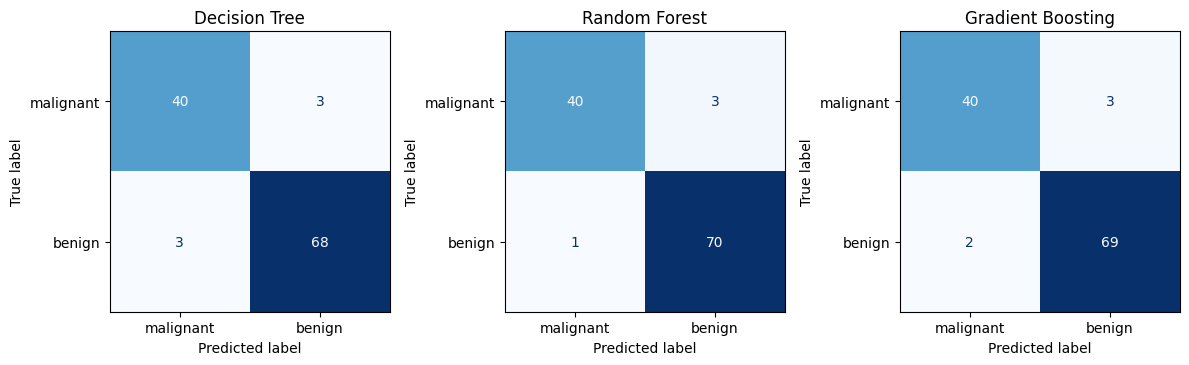

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

tree_models = {
	"Decision Tree": y_pred_dt,
	"Random Forest": y_pred_rf,
	"Gradient Boosting": y_pred_gb,
}

for ax, (name, y_pred) in zip(axes, tree_models.items()):
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
  disp.plot(ax=ax, cmap="Blues", colorbar=False)
  ax.set_title(name)

plt.tight_layout()
plt.show()

In summary:

The two ensemble methods outperform the decision tree because they provide better predictions.

##2. K-Nearest Neighbors (KNN) Model
Implement the K-Nearest Neighbors (KNN) classifier

Test multiple values of k (e.g., k = 1 to 20)

Plot model performance against different k-values

Identify the optimal value of k

###2.1 K-Nearest Neighbors (KNN)

**Identify optimal feature scaling:**

In [35]:
# Pipeline: z-Score + KNN
pipeline_zscore_knn = Pipeline([
  ('scaler', StandardScaler()),
  ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Pipeline: Min-Max + KNN
pipeline_minmax_knn = Pipeline([
  ('scaler', MinMaxScaler()),
  ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Cross-Validation
scores_zscore_knn = cross_val_score(pipeline_zscore_knn, X, y, cv=5, scoring='accuracy')
scores_minmax_knn = cross_val_score(pipeline_minmax_knn, X, y, cv=5, scoring='accuracy')

print("KNN mit z-Score:")
print(f" Mean: {scores_zscore_knn.mean():.5f} (+/- {scores_zscore_knn.std():.5f})")
print("\nKNN mit Min-Max:")
print(f" Mean: {scores_minmax_knn.mean():.5f} (+/- {scores_minmax_knn.std():.5f})")

KNN mit z-Score:
 Mean: 0.96485 (+/- 0.00961)

KNN mit Min-Max:
 Mean: 0.97188 (+/- 0.01163)


Result:

Both methods are nearly identical in terms of accuracy. The z-score is only more stable in terms of standard deviation. Since outliers can also be relevant in medical data (e.g. very large tumours), the z-score is the better choice here. A "reduction" to [0.1] would be negligent.

In [36]:
# Application z-score (outside the test pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_range = range(1, 21)
knn_scores = {"k": [], "Accuracy": [], "F1-Score": []}

for k in k_range:
	knn = KNeighborsClassifier(n_neighbors=k)
	knn.fit(X_train_scaled, y_train)
	y_pred_k = knn.predict(X_test_scaled)

	knn_scores["k"].append(k)
	knn_scores["Accuracy"].append(accuracy_score(y_test, y_pred_k))
	knn_scores["F1-Score"].append(f1_score(y_test, y_pred_k))

knn_df = pd.DataFrame(knn_scores)
print(knn_df.to_string(index=False))

# Besten k-Wert finden
best_k = knn_df.loc[knn_df['Accuracy'].idxmax()]
print(f"\nBest k-value: {int(best_k['k'])} with accuracy: {best_k['Accuracy']:.4f}")

 k  Accuracy  F1-Score
 1  0.938596  0.951049
 2  0.938596  0.950355
 3  0.947368  0.957746
 4  0.956140  0.964539
 5  0.947368  0.957746
 6  0.956140  0.964539
 7  0.947368  0.957746
 8  0.956140  0.964539
 9  0.964912  0.971831
10  0.956140  0.964539
11  0.956140  0.965035
12  0.956140  0.965035
13  0.956140  0.965035
14  0.956140  0.965035
15  0.956140  0.965035
16  0.956140  0.965035
17  0.947368  0.958333
18  0.956140  0.965035
19  0.947368  0.958333
20  0.956140  0.965035

Best k-value: 9 with accuracy: 0.9649


K=9 has the highest accuracy. The evaluation also shows the harmonic mean of precision and recall. This means that it is important to detect malignant cases, but also to avoid unnecessary examinations.

###2.2 Plot model performance against different k-values and identify the optimal value of k

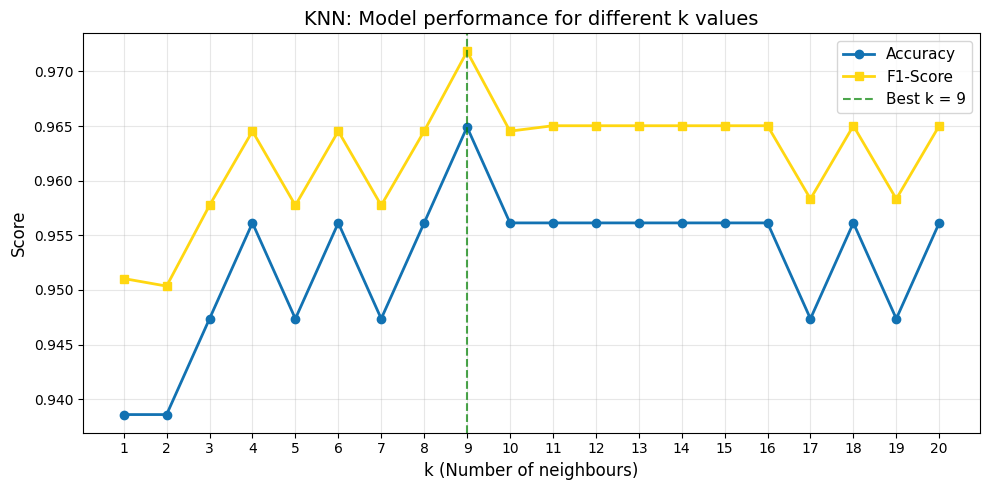


Best k-value: 9
Accuracy bei k=9: 0.9649


In [37]:
optimal_k = knn_df.loc[knn_df["Accuracy"].idxmax(), "k"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, knn_scores["Accuracy"], marker="o", label="Accuracy", color="#1272B2", linewidth=2)
ax.plot(k_range, knn_scores["F1-Score"], marker="s", label="F1-Score", color="#FFD711", linewidth=2)

# Best k
ax.axvline(x=optimal_k, color="green", linestyle="--", alpha=0.7,
	label=f"Best k = {optimal_k}")

ax.set_xlabel("k (Number of neighbours)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("KNN: Model performance for different k values", fontsize=14)
ax.set_xticks(k_range)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest k-value: {optimal_k}")
print(f"Accuracy bei k={optimal_k}: {knn_df.loc[knn_df['k'] == optimal_k, 'Accuracy'].values[0]:.4f}")

Interpretation:

The diagram shows that, in addition to the score achieved, the difference between accuracy and F1 score is also the smallest.

The performance is made even clearer by the following error identifier:

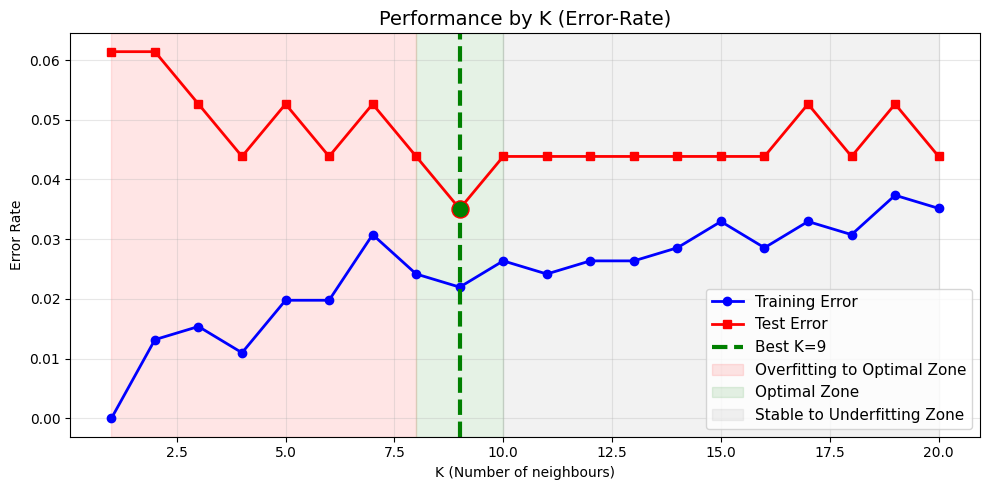

In [38]:

train_errors = []
test_errors = []

for k in k_range:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled, y_train)

  train_pred = knn.predict(X_train_scaled)
  test_pred = knn.predict(X_test_scaled)

  train_errors.append(1 - accuracy_score(y_train, train_pred))
  test_errors.append(1 - accuracy_score(y_test, test_pred))

"""
For comparison with the score, I found np.argmin to be a helpful error reference.
"""
best_k = k_range[np.argmin(test_errors)]

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_errors, 'b-o', label='Training Error', linewidth=2, markersize=6)
plt.plot(k_range, test_errors, 'r-s', label='Test Error', linewidth=2, markersize=6)

# Best k (in error test)
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=3,
  label=f'Best K={best_k}')
plt.scatter(best_k, test_errors[best_k-1], color='green', s=150,
  marker='o', zorder=5, edgecolor='red', linewidth=1)

plt.axvspan(1, 8, alpha=0.1, color='red', label='Overfitting to Optimal Zone')
plt.axvspan(8, 10, alpha=0.1, color='green', label='Optimal Zone')
plt.axvspan(10, 20, alpha=0.1, color='grey', label='Stable to Underfitting Zone')

plt.xlabel('K (Number of neighbours)', fontsize=10)
plt.ylabel('Error Rate', fontsize=10)
plt.title('Performance by K (Error-Rate)', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KNN (k=9) – Classification Report:

               precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



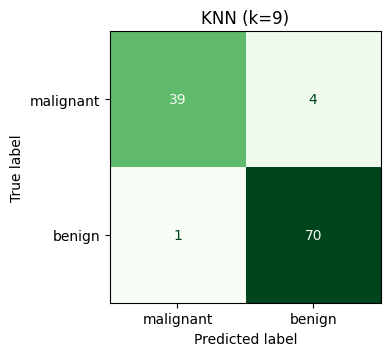

In [39]:
knn_best = KNeighborsClassifier(n_neighbors=int(optimal_k))
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)

print(f"KNN (k={optimal_k}) – Classification Report:")
print("\n", classification_report(y_test, y_pred_knn, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"KNN (k={optimal_k})")
plt.tight_layout()
plt.show()

Explanation of the 3 visualisations:

The three diagrams visualise how KNN works and how the optimal k-values are identified. The first two diagrams show the transition from overfitting (small K-values) to the optimal zone (K=9) to the underfitting zone (large K-values). It is clear that accuracy is lowest in the first k-values and fluctuates relatively strongly over the next ones up to K=9.

The confusion matrix for optimal K=9 shows how many false negatives (missed cancer cases) and false positives (false alarms) occurred:


*   **39 TP**
*   1 FP
*   4 FN
*   **70 TN**





##3. Evaluation Metrics
Evaluate all models using the following metrics:

Accuracy

Precision

Recall

F1-score

Present the results in a clear table or summary.

In [40]:
all_predictions = {
	"Decision Tree": y_pred_dt,
	"Random Forest": y_pred_rf,
	"Gradient Boosting": y_pred_gb,
	f"KNN (k={optimal_k})": y_pred_knn,
}

results = []
for name, y_pred in all_predictions.items():
	results.append({
		"Model": name,
		"Accuracy": accuracy_score(y_test, y_pred),
		"Precision": precision_score(y_test, y_pred),
		"Recall": recall_score(y_test, y_pred),
		"F1-Score": f1_score(y_test, y_pred),
	})

results_df = pd.DataFrame(results).set_index("Model")
results_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.9474,0.9577,0.9577,0.9577
Random Forest,0.9649,0.9589,0.9859,0.9722
Gradient Boosting,0.9561,0.9583,0.9718,0.9650
KNN (k=9),0.9561,0.9459,0.9859,0.9655


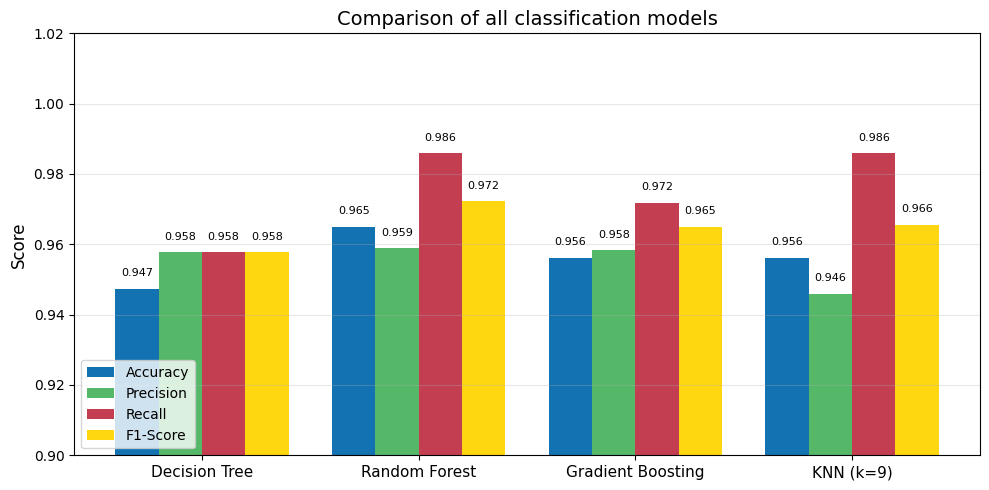

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.2
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["#1272B2", "#55B868", "#C43E52", "#FFD711"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
	bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color)
	for bar in bars:
		ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
			f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylim(0.90, 1.02)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparison of all classification models", fontsize=14)
ax.legend(fontsize=10, loc="lower left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion:

With a recall of 98.6%, KNN and Random Forest are the most suitable models. This means that only 1.4% of cancer cases are overlooked (false negatives). Only KNN has a slightly higher false alarm rate (precision is slightly lower).

In a medical context (especially in this one), overlooking a cancer case (false negative) is particularly critical. False alarms can be corrected, but undetected cases cannot. The example shows the sensitive assessment and interpretation of the terms and metrics.

In a real-world application, the model would have detected at least 98 out of 100 cancer patients. The false alarm rate would prompt further investigations. Here, it was proven that the model works very well when high-quality data is used.